In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("my_data_q.csv")
df.head()

,quesNo,subjects,lokNo,member,ministry,type,date,sessionNo,supplementaryType,year
0,3008,"Toll Plazas in Dharmapuri, Tamil Nadu ...",18,Shri Mani A,ROAD TRANSPORT AND HIGHWAYS,UNSTARRED,2025-12-18,6,False,2025
1,2960,Programmes to improve Connectivity/Lo...,18,Shri Mani A,RAILWAYS,UNSTARRED,2025-12-17,6,False,2025
2,2570,Schemes to promote Skill Development among Far...,18,Shri Mani A,AGRICULTURE AND FARMERS WELFARE,UNSTARRED,2025-12-16,6,False,2025
3,2401,Contribution of States in Tourism Industry ...,18,Shri Mani A,TOURISM,UNSTARRED,2025-12-15,6,False,2025
4,2226,Pharmacovigilance System for AYUSH Drugs,18,"Shri E T Mohammed Basheer, Shri Mani A",AYUSH,UNSTARRED,2025-12-12,6,False,2025


In [3]:
df = df[["subjects","ministry"]]

df.isnull().sum()

subjects    0
ministry    0
dtype: int64

In [5]:
df["ministry"].nunique()
print(df["ministry"].unique())

['ROAD TRANSPORT AND HIGHWAYS' 'RAILWAYS'
 'AGRICULTURE AND FARMERS WELFARE' 'TOURISM' 'AYUSH'
 'NEW AND RENEWABLE ENERGY' 'SKILL DEVELOPMENT AND ENTREPRENEURSHIP'
 'HEALTH AND FAMILY WELFARE' 'MICRO, SMALL AND MEDIUM ENTERPRISES'
 'PANCHAYATI RAJ' 'COMMUNICATIONS' 'RURAL DEVELOPMENT'
 'CONSUMER AFFAIRS, FOOD AND PUBLIC DISTRIBUTION' 'FINANCE' 'JAL SHAKTI'
 'ELECTRONICS AND INFORMATION TECHNOLOGY' 'LABOUR AND EMPLOYMENT'
 'COMMERCE AND INDUSTRY' 'FOOD PROCESSING INDUSTRIES' 'POWER'
 'ATOMIC ENERGY' 'TEXTILES' 'YOUTH AFFAIRS AND SPORTS'
 'WOMEN AND CHILD DEVELOPMENT' 'CULTURE' 'HOUSING AND URBAN AFFAIRS'
 'EDUCATION' 'LAW AND JUSTICE' 'PETROLEUM AND NATURAL GAS'
 'SOCIAL JUSTICE AND EMPOWERMENT' 'EARTH SCIENCES' 'EXTERNAL AFFAIRS'
 'ENVIRONMENT, FOREST AND CLIMATE CHANGE' 'HOME AFFAIRS'
 'PORTS, SHIPPING AND WATERWAYS' 'STATISTICS AND PROGRAMME IMPLEMENTATION'
 'COMMUNICATION' 'CIVIL AVIATION' 'STEEL' 'COOPERATION'
 'CHEMICALS AND FERTILIZERS' 'MINES' 'CORPORATE AFFAIRS' 'TRIBAL AFFAIRS

In [6]:
df["ministry"].value_counts().head(20)

ministry
HEALTH AND FAMILY WELFARE                         2170
AGRICULTURE AND FARMERS WELFARE                   1827
EDUCATION                                         1741
RAILWAYS                                          1706
JAL SHAKTI                                        1492
FINANCE                                           1309
HOUSING AND URBAN AFFAIRS                         1260
ROAD TRANSPORT AND HIGHWAYS                       1185
CIVIL AVIATION                                    1102
RURAL DEVELOPMENT                                 1066
WOMEN AND CHILD DEVELOPMENT                       1026
ENVIRONMENT, FOREST AND CLIMATE CHANGE             950
LABOUR AND EMPLOYMENT                              941
MICRO, SMALL AND MEDIUM ENTERPRISES                877
COMMERCE AND INDUSTRY                              805
CHEMICALS AND FERTILIZERS                          795
CONSUMER AFFAIRS, FOOD AND PUBLIC DISTRIBUTION     793
AYUSH                                              747
S

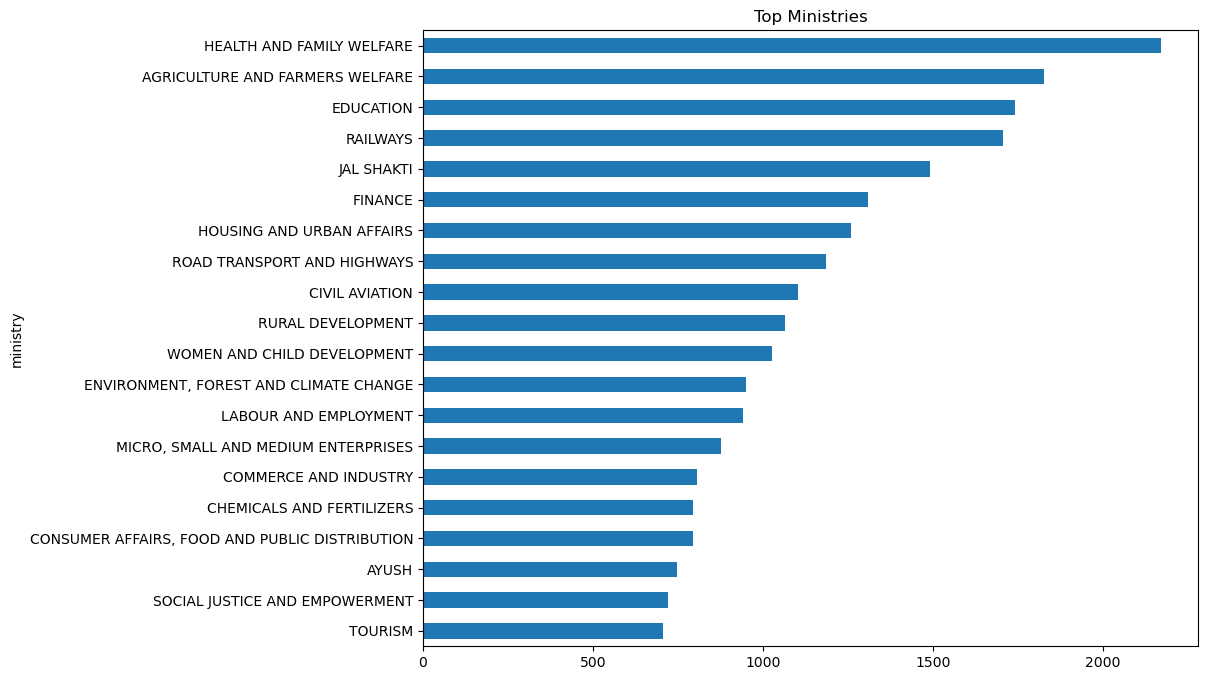

In [7]:
plt.figure(figsize=(10,8))

df["ministry"].value_counts().head(20).sort_values().plot(kind="barh")

plt.title("Top Ministries")

plt.show()

In [8]:
X = df["subjects"]

y = df["ministry"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [10]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [11]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
model.fit(
    X_train_tfidf,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
predictions = model.predict(
    X_test_tfidf
)
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:",accuracy)

Accuracy: 0.8511066398390342


In [14]:
print(
    classification_report(
        y_test,
        predictions
    )
)

                                                precision    recall  f1-score   support

               AGRICULTURE AND FARMERS WELFARE       0.83      0.89      0.86       366
                                 ATOMIC ENERGY       1.00      0.72      0.84        39
                                         AYUSH       0.96      0.87      0.91       149
                     CHEMICALS AND FERTILIZERS       0.90      0.87      0.88       159
                                CIVIL AVIATION       0.94      0.90      0.92       220
                                          COAL       0.93      0.77      0.84        82
                         COMMERCE AND INDUSTRY       0.75      0.86      0.80       161
                                 COMMUNICATION       0.75      0.86      0.80        92
                                COMMUNICATIONS       0.70      0.22      0.33        32
CONSUMER AFFAIRS, FOOD AND PUBLIC DISTRIBUTION       0.92      0.81      0.86       159
                               

In [17]:
cm = confusion_matrix(
    y_test,
    predictions
)
print(cm)

[[326   0   0 ...   0   2   0]
 [  0  28   0 ...   0   0   0]
 [  0   0 129 ...   0   0   0]
 ...
 [  1   0   0 ... 110   0   0]
 [  0   0   0 ...   1 196   0]
 [  0   0   0 ...   0   1 113]]


In [18]:
print("Number of Ministries:", df["ministry"].nunique())

Number of Ministries: 56


In [19]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}


In [20]:
from sklearn.metrics import accuracy_score

results = []

for name, model in models.items():

    model.fit(X_train_tfidf, y_train)

    pred = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, pred)

    results.append([name, acc])

results

[['Logistic Regression', 0.8511066398390342],
 ['Naive Bayes', 0.7590878604963112],
 ['Linear SVM', 0.8808853118712273],
 ['Random Forest', 0.8761904761904762]]

In [21]:
results = pd.DataFrame(
    results,
    columns=["Model", "Accuracy"]
)

results.sort_values(
    "Accuracy",
    ascending=False
)

,Model,Accuracy
2,Linear SVM,0.880885
3,Random Forest,0.876190
0,Logistic Regression,0.851107
1,Naive Bayes,0.759088


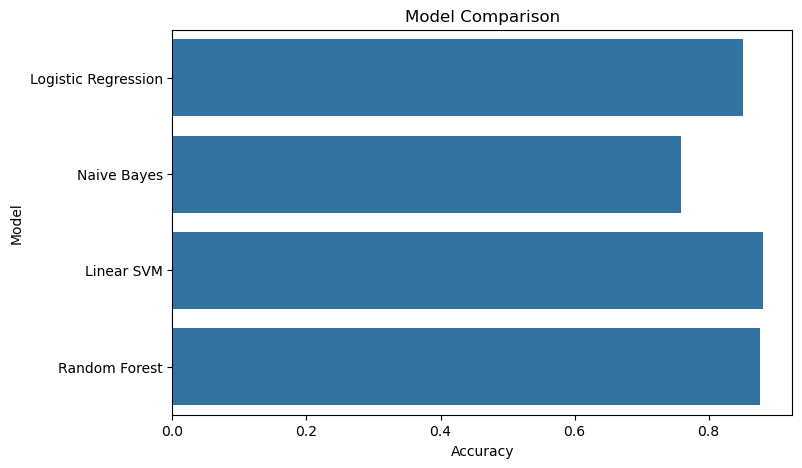

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Accuracy",
    y="Model"
)

plt.title("Model Comparison")

plt.show()

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Use multiclass friendly solvers
params = {
    "C": [0.1, 1, 5, 10],
    "solver": ["lbfgs", "saga"] 
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42), # Added random_state for consistency
    params,
    cv=5,
    scoring="f1_macro"
)

grid.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Macro F1-Score:", grid.best_score_)


Best Parameters: {'C': 10, 'solver': 'saga'}
Best Macro F1-Score: 0.8533571988399438


In [25]:
import joblib

joblib.dump(model, "ministry_model.pkl")

joblib.dump(vectorizer, "tfidf.pkl")

['tfidf.pkl']

In [26]:
sample = [
    "Construction of National Highways in Bihar"
]

vector = vectorizer.transform(sample)

prediction = model.predict(vector)

print(prediction[0])

ROAD TRANSPORT AND HIGHWAYS


In [28]:
sample = [
    "Farmer loan waiver"
]

vector = vectorizer.transform(sample)

prediction = model.predict(vector)

print(prediction[0])

AGRICULTURE AND FARMERS WELFARE


In [29]:
sample = [
    "Artificial Intelligence in Schools"
]

vector = vectorizer.transform(sample)

prediction = model.predict(vector)

print(prediction[0])

EDUCATION
